# Kashish Gupta
# Masters in Quantitative Economics, UCLA (706078348)

## "" DUAL CLASS ARBITRAGE TRADING STRATEGY WITH BACKTESTING AND TRADING BOT INTEGRATED TO ALPACA PAPER TRADING"

### Designate target dual-class shares

GOOGLE stock listing for dual class arbitrage: GOOG (class C) and GOOGL (class A)

### Investment Thesis

The arbitrage opportunity exists when either share is over/under valued compared to the other. For example, if there is a very large market order for GOOG that pushes the price up by 0.50%, but no such order existed for GOOGL, then GOOG will be 0.50% more valuable than GOOGL. An arbitrageur will see this imbalance and short GOOG shares and long GOOGL shares. As the imbalance corrects, they make money from both legs with no directional risk. This is. propoer market neutral strategy. 

- Here the trading strategy would be: 
1. Entry Criteria:
- Price Spread Trigger: Establish a threshold for the price spread between Class A and Class C shares that would trigger the arbitrage. We use regression to decide the spread. Threshold is +-1.5. When z-score crosses an upper threshold, go SHORT (sell stock GOOG and buy stock GOOGL). 

2. Position Sizing:
- Equal Dollar Amounts: Allocate equal dollar amounts to both the long and short positions to maintain a market-neutral stance.
- Leverage Considerations: no leverage used

3. Trade Execution:
- Algorithmic Orders: Use limit orders to avoid significant market impact, especially when dealing with large order sizes. We do not use limit orders for this project. 
- Timing: Execute trades during periods of high liquidity to minimize slippage. We only trade at the opening 1 hour when there is high liquidity. 

4. Exit Criteria:
- Profit Target: We exit the short position when spread falls below the threshold of 1.5 and when close long position when spread rises beyond -1.5
- Stop-Loss: Set a stop-loss level if the spread diverges further than a specific threshold from the entry point to limit losses. Here the stop loss is spread exceeding mean + 3* standard deviation

### Authenticate Alpaca API with Client ID and secret

In [ ]:
pip install alpaca_trade_api

In [80]:
import alpaca_trade_api as tradeapi

# API Info for fetching data, portfolio, etc. from Alpaca
BASE_URL = "https://paper-api.alpaca.markets"
ALPACA_API_KEY = "PKFOZMY4IMA7LLE6KTM6"
ALPACA_SECRET_KEY = "A9z3UDz11GgKGQBcNjl7ruf8xFxfJD64EKVQtW0g"

api = tradeapi.REST(key_id=ALPACA_API_KEY, secret_key=ALPACA_SECRET_KEY, 
                    base_url=BASE_URL, api_version='v2')
api

### Perform HTTP GET/POST requests to fetch information from Alpaca Trading Client

In [81]:
# Fetch Account
account = api.get_account()
# Print Account Details
print(account.id, account.equity, account.status)

42547ee8-0136-49e1-8bba-342e21e2c13c 100000 ACTIVE


### GET per minute live share pricing information for API for last 3 years

In [72]:
from alpaca.data import StockHistoricalDataClient, TimeFrame
from alpaca.data.requests import StockQuotesRequest, StockBarsRequest


# Instantiate a data client
data_client = StockHistoricalDataClient(ALPACA_API_KEY, ALPACA_SECRET_KEY)

# Set the start time
start_time = pd.to_datetime("2020-01-01").tz_localize('America/New_York')

request_params_googl = StockBarsRequest(
    symbol_or_symbols=['GOOGL', 'GOOG'],
    timeframe=TimeFrame.Minute,
    start=start_time
)

bars_df_googl_goog = pd.DataFrame(data_client.get_stock_bars(request_params_googl).df.tz_convert('America/New_York', level=1)['close']).reset_index()
pivot_df = bars_df_googl_goog.pivot(index='timestamp', columns='symbol', values='close')
pivot_df

symbol,GOOG,GOOGL
timestamp,,
2020-01-02 04:00:00-05:00,1342.2000,NaN
2020-01-02 04:02:00-05:00,1344.2000,NaN
2020-01-02 05:40:00-05:00,NaN,1351.00
2020-01-02 08:00:00-05:00,1337.0200,NaN
2020-01-02 08:09:00-05:00,1347.0000,NaN
...,...,...
2024-04-03 10:13:00-04:00,155.8500,154.45
2024-04-03 10:14:00-04:00,155.8100,154.41
2024-04-03 10:15:00-04:00,155.8900,154.50


### understand the Spread

/var/folders/1d/l6tryydj5ll_81bf6qw66y1m0000gn/T/ipykernel_90833/3934684033.py:17: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  pivot_df1['spread'] = spread


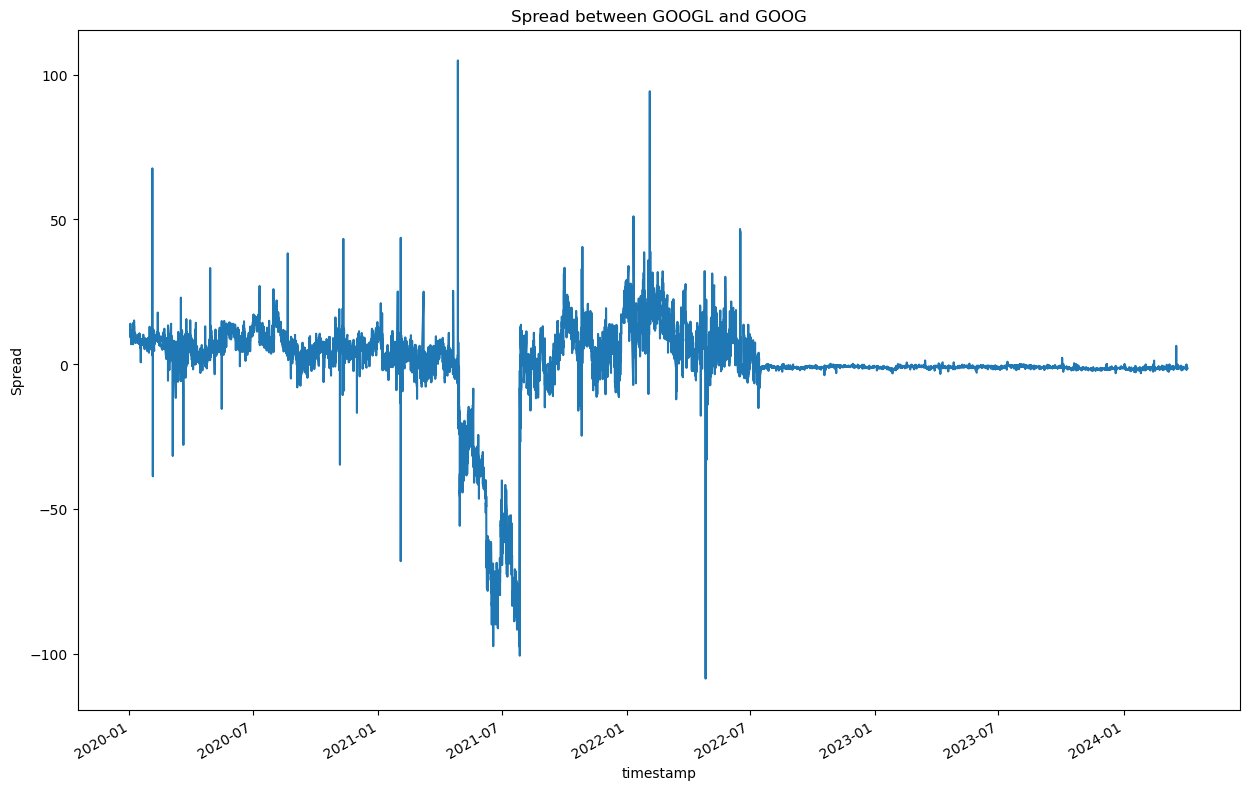

In [118]:
# find spread and check cointegration 
from sklearn import linear_model
import pandas as pd
import matplotlib.pyplot as plt

pivot_df1 = pivot_df.dropna()

x = pivot_df1['GOOG']
y = pivot_df1['GOOGL']

regr = linear_model.LinearRegression()
x_constant = pd.concat([x, pd.Series([1] * len(x), index=x.index, name='intercept')], axis=1)
regr.fit(x_constant, y)    
beta = regr.coef_[0]
alpha = regr.intercept_
spread = y - x * beta - alpha
pivot_df1['spread'] = spread

# Plotting the spread series
spread.plot(figsize=(15, 10))
plt.ylabel('Spread')
plt.title('Spread between GOOGL and GOOG')
plt.show()

In [119]:
import statsmodels.api as sm

# check if the spread is stationary 
adf = sm.tsa.stattools.adfuller(spread, maxlag=1)
print('ADF test statistic: %.02f' % adf[0])
for key, value in adf[4].items():
    print('\t%s: %.3f' % (key, value))
print('p-value: %.03f' % adf[1])

ADF test statistic: -15.57
	1%: -3.430
	5%: -2.862
	10%: -2.567
p-value: 0.000


Rejecting the null hypothesis means that the process has no unit root, and in turn that the spread is stationary or does not have time-dependent structure and hence conintegrated

### Create algorithm for margins at which to buy/sell short and long positions

/var/folders/1d/l6tryydj5ll_81bf6qw66y1m0000gn/T/ipykernel_90833/12521521.py:19: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  pivot_df1['time'] = pivot_df1.index.time  # Extract the time from the DateTimeIndex
/var/folders/1d/l6tryydj5ll_81bf6qw66y1m0000gn/T/ipykernel_90833/12521521.py:23: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  pivot_df1['z-score'] = z_score
/var/folders/1d/l6tryydj5ll_81bf6qw66y1m0000gn/T/ipykernel_90833/12521521.py:24: SettingWithCopyWarning: 
A value is trying to be set on a copy

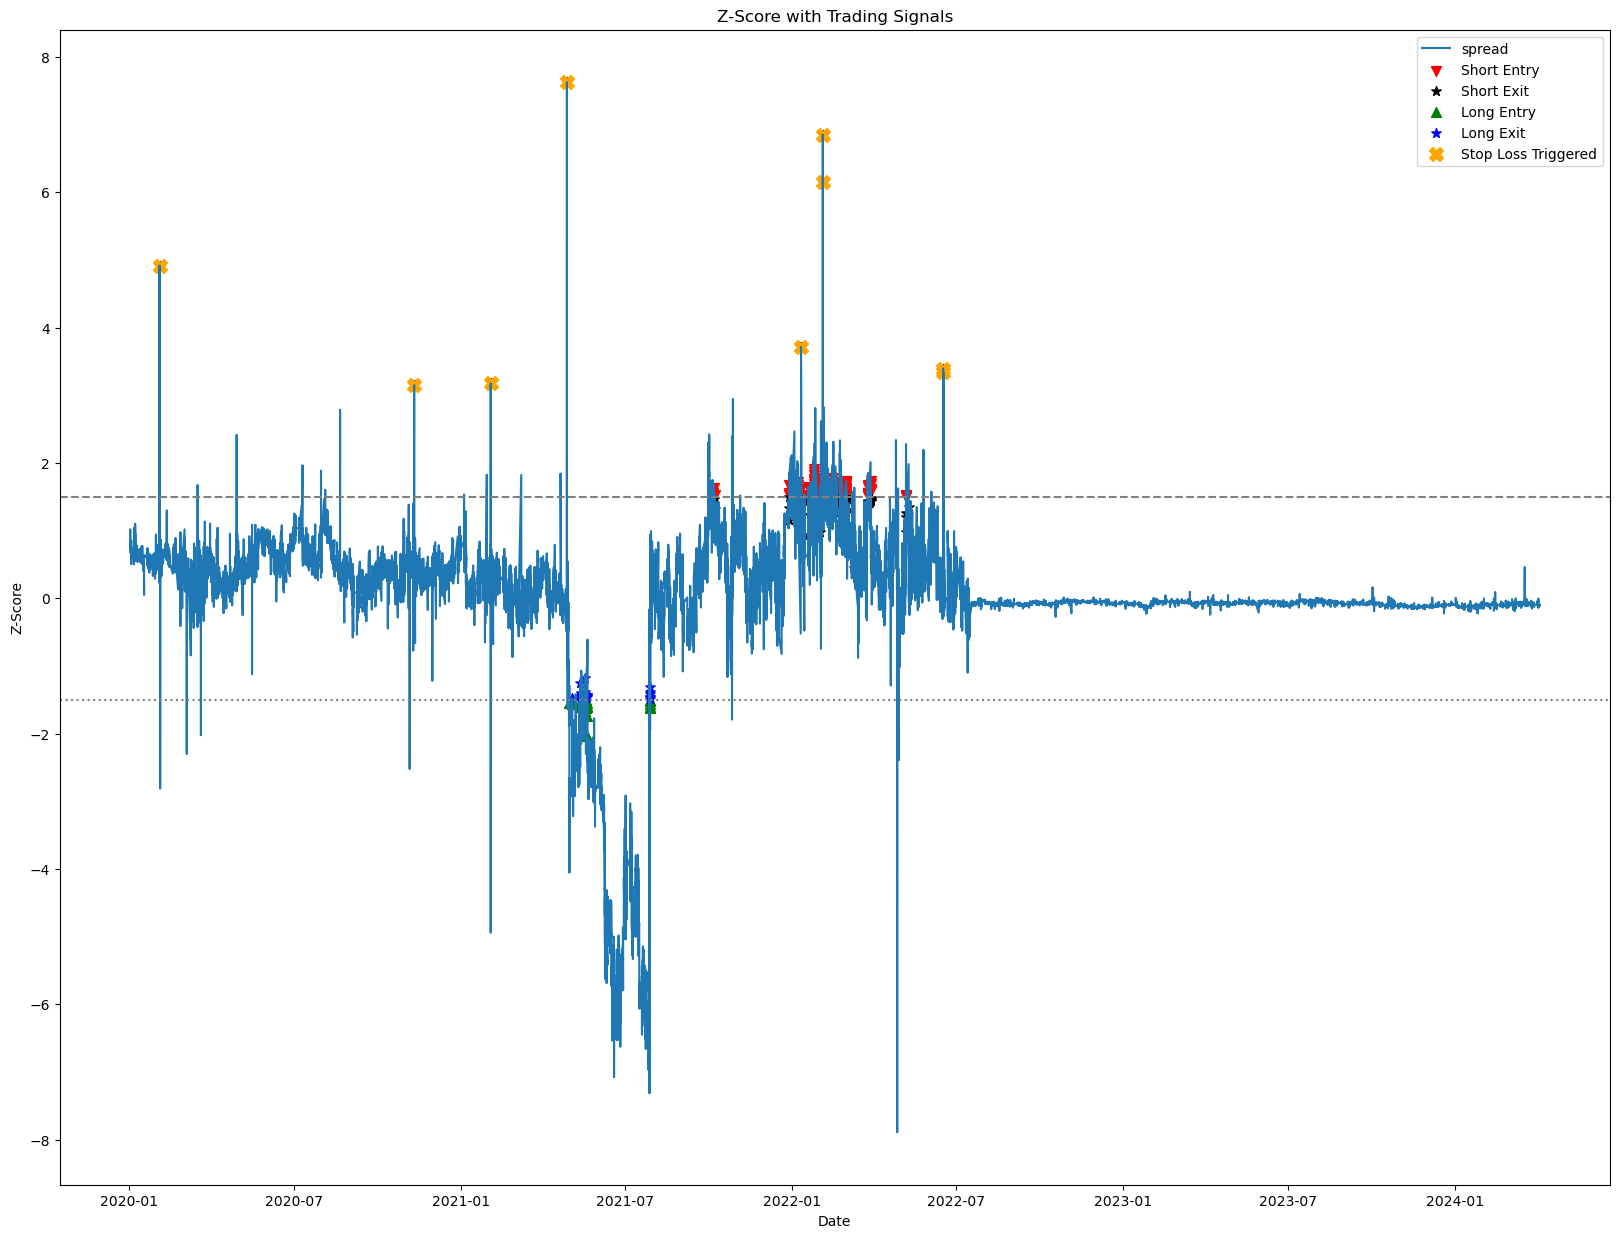

In [129]:
import numpy as np
from datetime import time

# generate entry points 
def calculate_z_score(spread):
    mean_spread = np.mean(spread)
    std_spread = np.std(spread)
    z_score = (spread - mean_spread) / std_spread
    return z_score, mean_spread, std_spread

z_score, mean_spread, std_spread = calculate_z_score(spread)

# threshold for spread 
signal_entry = 1.5
signal_exit = -1.5
stop_loss = mean_spread + 3*std_spread

# execute trade only in first one hour of opening of the market to ensure the liquidity 
pivot_df1['time'] = pivot_df1.index.time  # Extract the time from the DateTimeIndex
opening_hour_filter = pivot_df1['time'].between(time(9, 30), time(10, 30))

# merge with pricing data 
pivot_df1['z-score'] = z_score
pivot_df1['stop_loss_triggered'] = pivot_df1['spread'] > stop_loss

pivot_df1['short_signal'] = ((pivot_df1['z-score'] > signal_entry) & 
                        (pivot_df1['z-score'].shift(1) < signal_entry) & 
                        opening_hour_filter & 
                        ~pivot_df1['stop_loss_triggered'])

pivot_df1['short_exit'] = ((pivot_df1['z-score'] < signal_entry) & 
                      (pivot_df1['z-score'].shift(1) > signal_entry) & 
                      opening_hour_filter) | pivot_df1['stop_loss_triggered']

pivot_df1['long_signal'] = ((pivot_df1['z-score'] < signal_exit) & 
                       (pivot_df1['z-score'].shift(1) > signal_exit) & 
                       opening_hour_filter & 
                       ~pivot_df1['stop_loss_triggered'])

pivot_df1['long_exit'] = ((pivot_df1['z-score'] > signal_exit) & 
                     (pivot_df1['z-score'].shift(1) < signal_exit) & 
                     opening_hour_filter) | pivot_df1['stop_loss_triggered']

# plot
plt.figure(figsize = (20,15))
plt.plot(pivot_df1.index, pivot_df1['z-score'], label = 'spread')
# Plotting signals: marking the points where the signals are True
plt.scatter(pivot_df1.index[pivot_df1['short_signal']], pivot_df1['z-score'][pivot_df1['short_signal']], color='red', label='Short Entry', marker='v', s=50)
plt.scatter(pivot_df1.index[pivot_df1['short_exit']], pivot_df1['z-score'][pivot_df1['short_exit']], color='black', label='Short Exit', marker='*', s=50)
plt.scatter(pivot_df1.index[pivot_df1['long_signal']], pivot_df1['z-score'][pivot_df1['long_signal']], color='green', label='Long Entry', marker='^', s=50)
plt.scatter(pivot_df1.index[pivot_df1['long_exit']], pivot_df1['z-score'][pivot_df1['long_exit']], color='blue', label='Long Exit', marker='*', s=50)

# highlighting stop-loss
plt.scatter(pivot_df1.index[pivot_df1['stop_loss_triggered']], pivot_df1['z-score'][pivot_df1['stop_loss_triggered']], color='orange', label='Stop Loss Triggered', marker='X', s=100)

plt.axhline(y=signal_entry, color='grey', linestyle='--')
plt.axhline(y=signal_exit, color='grey', linestyle=':')

plt.title('Z-Score with Trading Signals')
plt.ylabel('Z-Score')
plt.xlabel('Date')
plt.legend()
plt.show()

### Backtesting

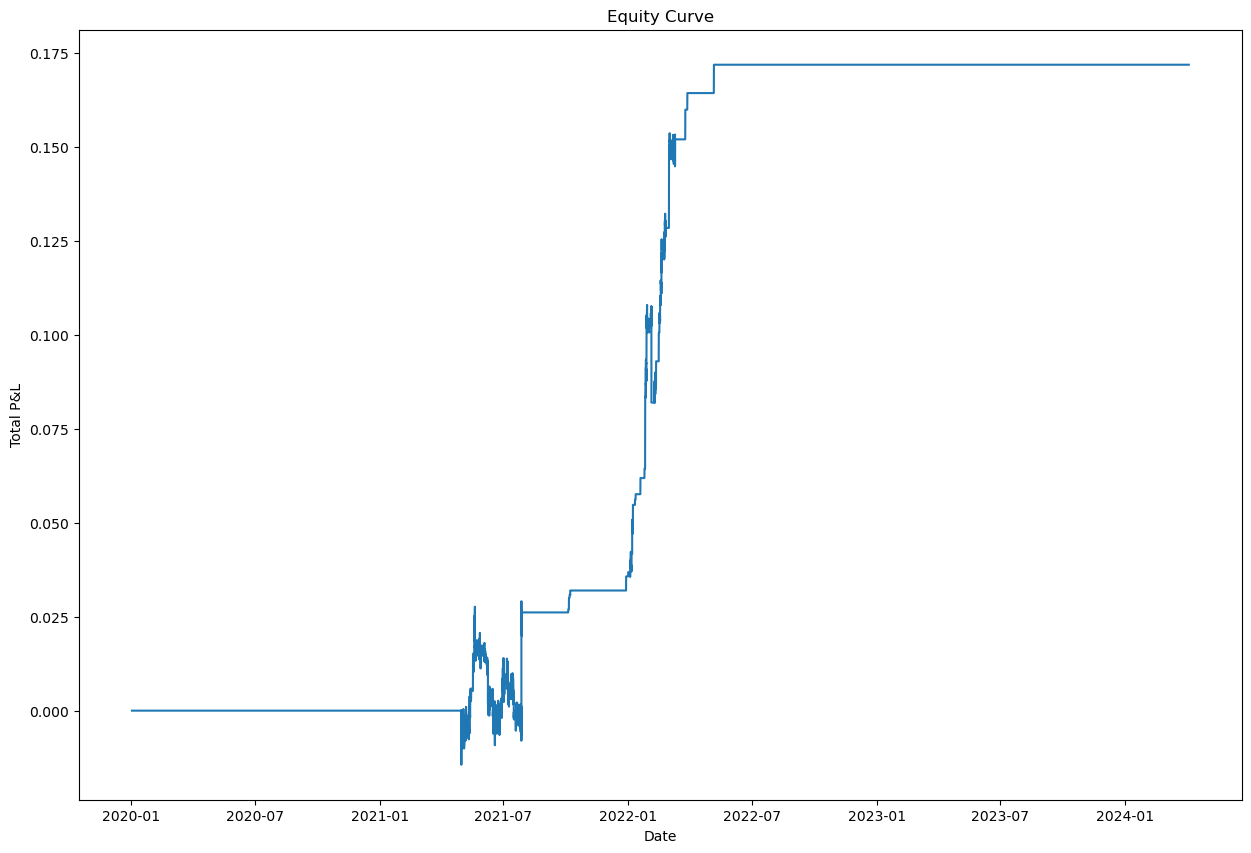

In [124]:
# backtest it using equity curve

data1 = pivot_df1.copy()
data1['GOOG_returns'] = data1['GOOG'].pct_change()
data1['GOOGL_returns'] = data1['GOOGL'].pct_change()
data1 = data1.dropna()
data1 = data1.iloc[:,7:]

spread_side = None
backtest_result = []
for time, signals_stock in data1.iterrows():
    short_signal, short_exit, long_signal, long_exit, GOOG_return, GOOGL_return = signals_stock
    return_stock2 = return_stock1 = 0  # Initialize returns
    
    if spread_side == 'long': # the spread is negative then Y (GOOGL) is undervalued so go long 
        # Long GOOGL, Short GOOG
        return_stock2 = GOOGL_return
        return_stock1 = -GOOG_return
        
        if long_exit:
            spread_side = None  # Close the long position
            
    elif spread_side == 'short':
        # Short GOOGL, Long GOOG
        return_stock2 = -GOOGL_return
        return_stock1 = GOOG_return
        
        if short_exit:
            spread_side = None  # Close the short position
            
    elif spread_side is None and short_signal: # if there is no open position and a short signal is triggered
        spread_side = 'short'  # Open a short position
        
    elif spread_side is None and long_signal:
        spread_side = 'long'  # Open a long position
    
    # Append results
    backtest_result.append([time, return_stock2, return_stock1])

# Create a DataFrame from the backtest results
backtest_df = pd.DataFrame(backtest_result, columns=['Date', 'GOOGL_return', 'GOOG_return'])
backtest_df['total_returns'] = backtest_df['GOOGL_return'] + backtest_df['GOOG_return']
backtest_df['total_pnl'] = (1 + backtest_df['total_returns']).cumprod() - 1
backtest_df.set_index('Date', inplace=True)

# Plot the equity curve
plt.figure(figsize = (15,10))
plt.plot(backtest_df['total_pnl'])
plt.title('Equity Curve')
plt.xlabel('Date')
plt.ylabel('Total P&L')
plt.show()

In [144]:
# calculate metrics 


# for easy calculation of backtest metrics - convert per minute data to daily data
daily_simple_returns = backtest_df['total_returns'].add(1).resample('D').prod().sub(1)

# Annualized Returns 
annualized_returns = ((1 + daily_simple_returns.mean()) ** 252 - 1)*100

# Sharpe Ratio
sharpe_ratio = (daily_simple_returns.mean() / daily_simple_returns.std()) * (252 ** 0.5)

# Win Rate
win_trades =daily_simple_returns[daily_simple_returns> 0].count()
total_trades = daily_simple_returns.count()
win_rate = (win_trades / total_trades) * 100


print(f'annualized_return is {annualized_returns}%')
print(f'sharpe ratio is {sharpe_ratio}')
print(f'win rate is {win_rate}%')


annualized_return is 2.637070509871098%
sharpe ratio is 1.0530180899030317
win rate is 4.247104247104247%


### Set up Python Scheduler to send necessary API calls every 1 minute, 930-1030 am, Mon - Fri

In [ ]:
import datetime
import time as time_module 

def fetch_price_data():
    """Fetch real-time per minute price data for GOOG and GOOGL for last two minutes"""
    goog_data = api.get_bars('GOOG', TimeFrame.Minute, limit=2).df['close']
    googl_data = api.get_bars('GOOGL', TimeFrame.Minute, limit=2).df['close']
    return goog_data, googl_data

def filter_first_hour_data(pivot_df):
    """Assuming 'df' has a datetime index."""
    # time is in UTC 
    market_open = datetime.time(14, 30)  
    one_hour_later = datetime.time(15, 30) 

    # Filter for the first hour (2:30 pm to 3:30pm UTC)
    first_hour_data = pivot_df.between_time(market_open, one_hour_later)
    return first_hour_data

def calculate_spread(filtered_goog, filtered_googl):
    """Calculate the spread based on your model. Placeholder function."""
    # Calculate z-score using regression
    spread = filtered_googl - filtered_goog*beta - alpha  
    z_score_spread = calculate_z_score(spread)
    return z_score_spread


class TradingSignalGenerator:
    def __init__(self):
        self.position = 'neutral'  # Tracks the current position: 'neutral', 'long', or 'short'

    # generate a signal only in the first hour of trading (2:30 pm to 3:30pm)
    def generate_signals(self, z_score_spread):
        """Generate trading signals based on the spread, ensuring exits follow entries."""
        if self.position == 'neutral':
            if (z_score_spread.iloc[-1] > 1.5) & (z_score_spread.iloc[-2] < 1.5) & ~(spread>stop_loss):
                self.position = 'short'
                return 'short entry'
            elif (z_score_spread.iloc[-1] < -1.5) & (z_score_spread.iloc[-2] > -1.5) & ~(spread>stop_loss):
                self.position = 'long'
                return 'long entry'
        
        elif self.position == 'short':
            if (z_score_spread.iloc[-1] < 1.5) & (z_score_spread.iloc[-2] > 1.5) & (spread>stop_loss):
                self.position = 'neutral'
                return 'short exit'
        
        elif self.position == 'long':
            if (z_score_spread.iloc[-1] > -1.5) & (z_score_spread.iloc[-2] < -1.5) & (spread>stop_loss):
                self.position = 'neutral'
                return 'long exit'
        
        return 'hold'
    
    
def place_trade(signal):
    """Place trades based on the signal."""
    if signal == 'long entry' or signal == 'short exit' :
        api.submit_order(symbol='GOOGL', qty=1, side='buy', type='market', time_in_force='gtc')
        api.submit_order(symbol='GOOG', qty=1, side='sell', type='market', time_in_force='gtc')
    elif signal == 'short entry' or signal == 'long exit':
        api.submit_order(symbol='GOOGL', qty=1, side='sell', type='market', time_in_force='gtc')
        api.submit_order(symbol='GOOG', qty=1, side='buy', type='market', time_in_force='gtc')

def trading_bot():
    """Main function to run the trading bot."""
    goog_price, googl_price = fetch_price_data()

    filtered_goog = filter_first_hour_data(goog_price)
    filtered_googl = filter_first_hour_data(googl_price)

    if not filtered_goog.empty and not filtered_googl.empty:
        z_score_spread = calculate_spread(filtered_goog, filtered_googl)

        if len(z_score_spread) >= 2:  # Check if there are at least two data points
            signal_generator = TradingSignalGenerator()  
            signal = signal_generator.generate_signals(z_score_spread)
            if signal != 'hold':
                place_trade(signal)
        else:
            print("Not enough data for signal generation.")
    else:
        print("Filtered data is empty.")


# Main loop
if __name__ == '__main__':
    while True:
        trading_bot()
        time_module.sleep(60)
